In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Optimization and Saving
import optuna
import joblib
import warnings

# Settings
sns.set(style="whitegrid")
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

print("Libraries imported. ")

Libraries imported. 


In [2]:
# --- CONFIGURATION ---
TARGET_COLUMN = 'families'
INPUT_RAW_FILE = '../../../../data/typhoon_impact_with_extreme_weather.csv'

# 1. Load Data
try:
    print(f"ANALYSIS TARGET: {TARGET_COLUMN}")
    df = pd.read_csv(INPUT_RAW_FILE)
    
    # 2. Standardize Column Names
    df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_').str.replace('/', '_')
    
    # 3. Rename columns (Adjust if your raw file is different)
    rename_map = {
        'typhoon': 'typhoon_name',
        'wind_speed': 'max_sustained_wind_kph',
        'rainfall': 'max_24hr_rainfall_mm',
        'pressure': 'min_pressure_hpa',
        'storm_rainfall': 'total_storm_rainfall_mm'
    }
    df.rename(columns=rename_map, inplace=True)

    # 4. Clean Target Column (Handle commas and NaNs)
    if TARGET_COLUMN in df.columns:
        if df[TARGET_COLUMN].dtype == 'object':
            df[TARGET_COLUMN] = df[TARGET_COLUMN].astype(str).str.replace(',', '')
        df[TARGET_COLUMN] = pd.to_numeric(df[TARGET_COLUMN], errors='coerce').fillna(0)
    else:
        raise ValueError(f"Target '{TARGET_COLUMN}' not found in dataset.")

    # 5. FILTER: Keep only rows where Target > 0 (Remove 0s)
    df_clean = df[df[TARGET_COLUMN] > 0].copy()
    
    # 6. Handle Missing Weather Data (Fill with Median)
    weather_cols = ['max_sustained_wind_kph', 'max_24hr_rainfall_mm', 'total_storm_rainfall_mm', 'min_pressure_hpa']
    for col in weather_cols:
        if col in df_clean.columns:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    print(f"Data Loaded & Cleaned.")
    print(f"Original Rows: {len(df)}")
    print(f"Training Rows (Target > 0): {len(df_clean)}")
    print(f"Rows Removed: {len(df) - len(df_clean)}")

except FileNotFoundError:
    print(f"Error: '{INPUT_RAW_FILE}' not found.")

ANALYSIS TARGET: families
Data Loaded & Cleaned.
Original Rows: 1776
Training Rows (Target > 0): 1569
Rows Removed: 207


In [3]:
# --- DATA EXPLORATION ---
print(f"DATASET SUMMARY (Filtered Data for '{TARGET_COLUMN}')")
print(f"Total Rows: {df_clean.shape[0]}")
print(f"Total Columns: {df_clean.shape[1]}")
print("-" * 50)

print("\n--- Dataset Information (Data Types) ---")
df_clean.info()

print("\n--- Summary Statistics (Check for outliers) ---")
# .T makes it easier to read if you have many columns
print(df_clean.describe().T)

print("\n--- Missing Values Check ---")
print(df_clean.isnull().sum())

print("-" * 50)
print("--- Preview of First 5 Rows ---")
df_clean.head(5)

DATASET SUMMARY (Filtered Data for 'families')
Total Rows: 1569
Total Columns: 30
--------------------------------------------------

--- Dataset Information (Data Types) ---
<class 'pandas.core.frame.DataFrame'>
Index: 1569 entries, 0 to 1775
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   typhoon_name             1569 non-null   object 
 1   year                     1569 non-null   int64  
 2   region                   1569 non-null   int64  
 3   province                 1569 non-null   object 
 4   city_municipality        1569 non-null   object 
 5   families                 1569 non-null   int64  
 6   person                   1569 non-null   int64  
 7   brgy                     1569 non-null   int64  
 8   dead                     1569 non-null   int64  
 9   injured_ill              1569 non-null   int64  
 10  missing                  1569 non-null   int64  
 11  totally         

,typhoon_name,year,region,province,city_municipality,families,person,brgy,dead,injured_ill,...,par_end,duration_in_par_hours,max_sustained_wind_kph,typhoon_type,max_24hr_rainfall_mm,total_storm_rainfall_mm,min_pressure_hpa,weather_station_mapped,weather_records_found,weather_days_covered
0,BETTY,2023,2,BATANES,BASCO,3608,11120,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
1,BETTY,2023,2,BATANES,ITBAYAT,968,3028,5,0,0,...,6/1/2023,133.0,195,STY,20.3,32.71,1000.5,1,6,6
2,BETTY,2023,2,BATANES,IVANA,444,1532,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
3,BETTY,2023,2,BATANES,MAHATAO,575,1792,4,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6
4,BETTY,2023,2,BATANES,SABTANG,575,1955,6,0,0,...,6/1/2023,133.0,195,STY,25.6,39.00,977.1,1,6,6


In [4]:
# Define Features (Duration and Typhoon Type removed)
input_features = [
    'max_sustained_wind_kph',
    'max_24hr_rainfall_mm',
    'total_storm_rainfall_mm',
    'min_pressure_hpa'
]

# Select X and y
X = df_clean[input_features]
y = df_clean[TARGET_COLUMN]

# Split Data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Data Split Complete.")
print(f"Training Samples: {X_train_raw.shape[0]}")
print(f"Testing Samples:  {X_test_raw.shape[0]}")

Data Split Complete.
Training Samples: 1255
Testing Samples:  314


In [6]:
# Initialize Scaler
scaler = StandardScaler()

# Fit on Train, Transform both Train and Test
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print("Features Scaled.")
print(f"Train Shape: {X_train.shape}")
print(f"Test Shape:  {X_test.shape}")

Features Scaled.
Train Shape: (1255, 4)
Test Shape:  (314, 4)


In [7]:
# Initialize and Train
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

# Predict on Test Set
y_pred_base = np.maximum(baseline_model.predict(X_test), 0)

# Evaluate Baseline
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))

print(f"BASELINE MODEL RESULTS:")
print(f"R2 Score: {base_r2:.4f}")
print(f"RMSE:     {base_rmse:,.2f}")

BASELINE MODEL RESULTS:
R2 Score: 0.0005
RMSE:     4,312.34


In [42]:
def objective(trial):
    # Suggest alpha (regularization strength)
    alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
    
    model = Ridge(alpha=alpha)
    
    # Cross Validation (3-fold if possible, else 2-fold)
    cv_folds = 3 if len(X_train) > 10 else 2
    
    # We optimize for Negative MSE (closer to 0 is better)
    score = cross_val_score(model, X_train, y_train, cv=cv_folds, scoring='neg_mean_squared_error')
    return score.mean()

# Run Optimization
print("Starting Optuna Tuning...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

best_alpha = study.best_params['alpha']
print(f"Tuning Complete. Best Alpha: {best_alpha:.4f}")

Starting Optuna Tuning...


Tuning Complete. Best Alpha: 99.0929


In [43]:
# Initialize Ridge with Best Alpha
final_model = Ridge(alpha=best_alpha)

# Train on full training data
final_model.fit(X_train, y_train)

print("Final Tuned Model Trained.")

Final Tuned Model Trained.


In [44]:
# --- COMPARISON: BASELINE vs TUNED MODEL ---
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# 1. Get Predictions
y_pred_base = np.maximum(baseline_model.predict(X_test), 0)
y_pred_tuned = np.maximum(final_model.predict(X_test), 0)

# 2. Calculate Metrics for Baseline
base_r2 = r2_score(y_test, y_pred_base)
base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_base))
base_mae = mean_absolute_error(y_test, y_pred_base)

# 3. Calculate Metrics for Tuned Model
tuned_r2 = r2_score(y_test, y_pred_tuned)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_mae = mean_absolute_error(y_test, y_pred_tuned)

# 4. Create Comparison Table
comparison_df = pd.DataFrame({
    'Metric': ['R² Score', 'RMSE', 'MAE'],
    'Baseline Model': [base_r2, base_rmse, base_mae],
    'Optuna Tuned Model': [tuned_r2, tuned_rmse, tuned_mae],
    'Improvement': [
        tuned_r2 - base_r2,           # Higher R2 is better
        base_rmse - tuned_rmse,       # Lower RMSE is better (Positive = Improvement)
        base_mae - tuned_mae          # Lower MAE is better (Positive = Improvement)
    ]
})

# Formatting for cleaner output
print(f"⚖️ MODEL COMPARISON REPORT ({TARGET_COLUMN.upper()})")
print("=" * 60)
print(comparison_df.to_string(index=False, float_format="%.4f"))
print("=" * 60)

# Quick Interpretation
if tuned_rmse < base_rmse:
    print(f"✅ SUCCESS: Optuna tuning improved RMSE by {base_rmse - tuned_rmse:,.2f}")
else:
    print(f"⚠️ NOTE: Tuning did not significantly improve performance (Model might be limited by data quality).")

⚖️ MODEL COMPARISON REPORT (FAMILIES)
  Metric  Baseline Model  Optuna Tuned Model  Improvement
R² Score          0.0005              0.0020       0.0015
    RMSE       4312.3414           4309.0810       3.2604
     MAE       1798.5508           1799.9385      -1.3877
✅ SUCCESS: Optuna tuning improved RMSE by 3.26


FINAL PERFORMANCE (FAMILIES)
R2 Score: 0.0020
RMSE:     4,309.08
MAE:      1,799.94


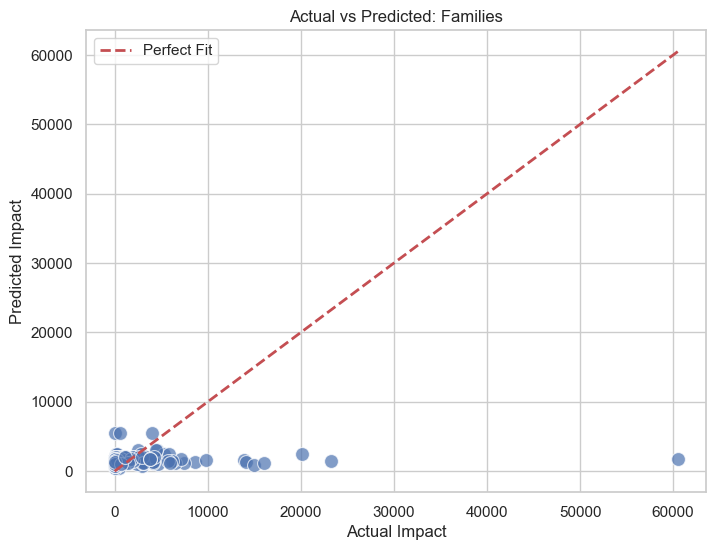

In [45]:
# Predict on Test Set
y_pred_final = np.maximum(final_model.predict(X_test), 0)

# Calculate Metrics
r2 = r2_score(y_test, y_pred_final)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae = mean_absolute_error(y_test, y_pred_final)

print(f"FINAL PERFORMANCE ({TARGET_COLUMN.upper()})")
print(f"R2 Score: {r2:.4f}")
print(f"RMSE:     {rmse:,.2f}")
print(f"MAE:      {mae:,.2f}")

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_final, alpha=0.7, s=100)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.title(f'Actual vs Predicted: {TARGET_COLUMN.capitalize()}')
plt.xlabel('Actual Impact')
plt.ylabel('Predicted Impact')
plt.legend()
plt.show()

In [53]:
# --- 1. Prepare Output Data ---
# Define the metadata columns you want to include
meta_cols = ['typhoon_name', 'province', 'city_municipality', 'year']

# Check which ones are actually in your dataframe to avoid errors
available_meta = [c for c in meta_cols if c in df_clean.columns]

# Retrieve the metadata for the specific rows in the test set using the index
test_metadata = df_clean.loc[y_test.index, available_meta].copy()

# Create the prediction results dataframe
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': np.round(y_pred_final, 2),
    'Difference': np.round(y_test.values - y_pred_final, 2)
}, index=y_test.index)

# Concatenate the metadata with the results
final_output = pd.concat([test_metadata, results_df], axis=1)

# --- SORTING STEP ---
# Sort by Typhoon Name (A-Z) then Year (Ascending)
if 'typhoon_name' in final_output.columns and 'year' in final_output.columns:
    final_output.sort_values(by=['typhoon_name', 'year'], ascending=[True, True], inplace=True)

# --- 2. Save to CSV ---
csv_filename = f'results_lr_{TARGET_COLUMN}.csv' 
final_output.to_csv(csv_filename, index=False)

print(f"✅ Results saved to {csv_filename}")
print("Preview of columns in CSV:")
display(final_output.head())

✅ Results saved to results_lr_families.csv
Preview of columns in CSV:


,typhoon_name,province,city_municipality,year,Actual,Predicted,Difference
1733,AGATON,SOUTHERN LEYTE,TOMAS OPPUS,2022,274,775.27,-501.27
1403,AGATON,BILIRAN,CABUCGAYAN,2022,102,950.23,-848.23
1730,AGATON,SOUTHERN LEYTE,LIBAGON,2022,157,775.27,-618.27
1538,AGATON,LEYTE,PALO,2022,140,968.08,-828.08
1539,AGATON,LEYTE,PALOMPON,2022,4659,968.08,3690.92


In [47]:
# --- MANUAL VALIDATION FUNCTION ---
def test_prediction(wind_kph, rain_24hr, storm_rain_mm, pressure_hpa):
    """
    Tests the model with custom values to validate logic.
    """
    # 1. Create a DataFrame with the input data (Must match training features)
    input_data = pd.DataFrame({
        'max_sustained_wind_kph': [wind_kph],
        'max_24hr_rainfall_mm': [rain_24hr],
        'total_storm_rainfall_mm': [storm_rain_mm],
        'min_pressure_hpa': [pressure_hpa]
    })

    # 2. Scale the input using the SAME scaler from training
    # (Crucial: The model expects scaled data, not raw numbers)
    input_scaled = scaler.transform(input_data)

    # 3. Predict
    prediction = final_model.predict(input_scaled)
    
    # 4. Handle negative predictions (convert to 0)
    final_value = max(prediction[0], 0)

    print(f"🧪 TEST INPUTS:")
    print(f"   Wind: {wind_kph} kph | Rain (24h): {rain_24hr} mm | Pressure: {pressure_hpa} hPa")
    print(f"   -----------------------------------------------------------")
    print(f"   🔮 PREDICTED {TARGET_COLUMN.upper()}: {final_value:,.2f}")
    print(f"   -----------------------------------------------------------\n")

In [48]:
test_prediction(wind_kph=100, rain_24hr=80, storm_rain_mm=150, pressure_hpa=980)

🧪 TEST INPUTS:
   Wind: 100 kph | Rain (24h): 80 mm | Pressure: 980 hPa
   -----------------------------------------------------------
   🔮 PREDICTED FAMILIES: 2,240.84
   -----------------------------------------------------------



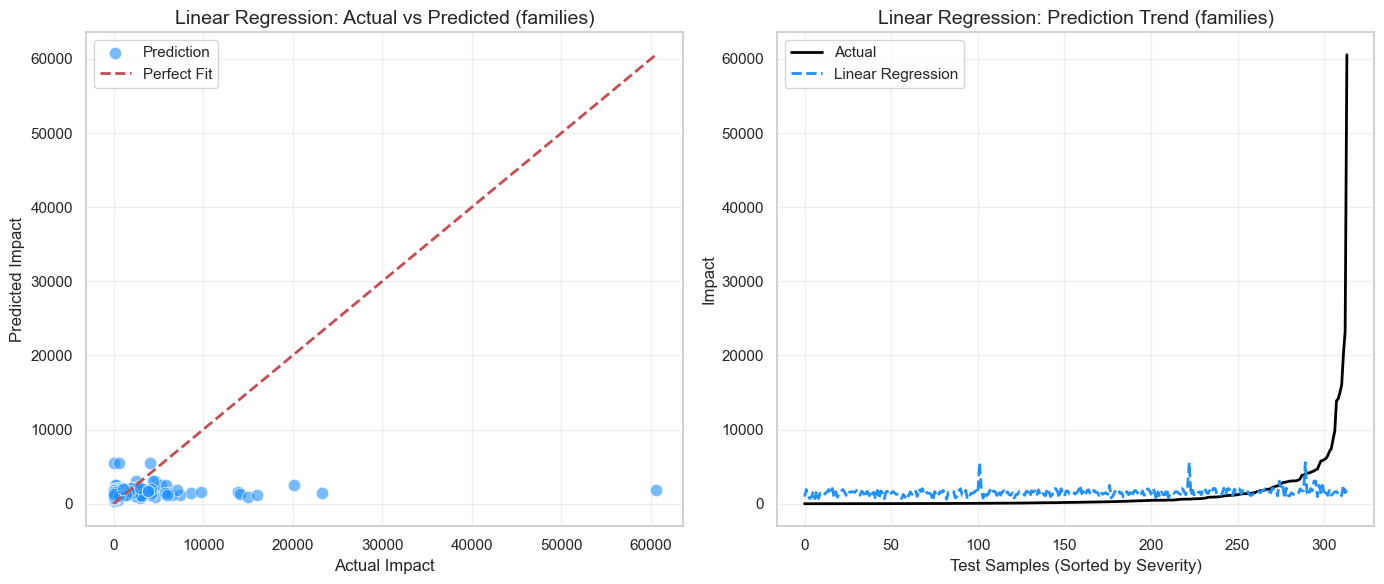

In [49]:
# --- LINEAR REGRESSION VISUALIZATION ---
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Plot A: Actual vs Predicted (Scatter)
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred_final, color='dodgerblue', alpha=0.6, s=80, label='Prediction')
# Perfect Line
min_val = min(y_test.min(), y_pred_final.min())
max_val = max(y_test.max(), y_pred_final.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Fit')

plt.title(f'Linear Regression: Actual vs Predicted ({TARGET_COLUMN})', fontsize=14)
plt.xlabel('Actual Impact')
plt.ylabel('Predicted Impact')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot B: Trend Line (Sorted)
plt.subplot(1, 2, 2)
# Sort by Actual values to see the trend
sorted_idx = np.argsort(y_test.values)
plt.plot(y_test.values[sorted_idx], label='Actual', color='black', linewidth=2)
plt.plot(y_pred_final[sorted_idx], label='Linear Regression', color='dodgerblue', linestyle='--', linewidth=2)

plt.title(f'Linear Regression: Prediction Trend ({TARGET_COLUMN})', fontsize=14)
plt.xlabel('Test Samples (Sorted by Severity)')
plt.ylabel('Impact')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()